## **Preprocesamiento MSP-IMPROV y Extracción de Características**

Para la evaluación de la **transferencia de aprendizaje** del modelo entrenado sobre el corpus global, se ha seleccionado un tercer dataset (**MSP-Improv**), el cual preprocesaremos a continuación siguiendo el mismo flujo de trabajo indicado en la metodología, que puede definirse como un pipeline **ETL (Extract, Transform, Load)**:

1. **Extracción e Integridad (Extract):** Esta primera fase corresponde al paso de "Análisis inicial" del pipeline de preprocesamiento en la metodología. Primero, cargaremos los metadatos originales en una estructura de datos tabular, verificando la existencia de cada archivo de vídeo, audio y transcripción asociada a cada turno de palabra. Gracias a que tanto vídeo/audio/transcripción se encuentran por separado y segmentados por turno de palabra individual, no se extraerán ni dividirán.   

2. **Transformación y Normalización (Transform):** 
Esta segunda fase corresponde a los pasos de "Limpieza de datos" y "Armonización de etiquetas" en el pipeline de preprocesamiento en la metodología. 
    * Detección y tratamiento de **valores faltantes (NaN)**, **duplicados** (completos e IDs) y ***outliers técnicos*** (errores). 
    * Corrección de rutas de archivos no estándar (especialmente en el conjunto de *test*).
    * **Estandarización** de formatos y codificaciones.
    * **Generación del Target (Variable Objetivo):** Creación de la variable binaria `target_stress` (Estrés vs. No Estrés) mediante el mapeo de VAD basado en el **Modelo Circumplejo de Russell** (Alta Activación + Valencia Negativa).

3.  **Carga (Load):** Consolidación de los datos limpios en un único archivo (`MSP-Improv_clean.csv`) listo para la evaluación de transferencia de aprendizaje. 

4. **Extracción de características**: Con los extractores seleccionados (**ResNet** + **RoBERTa** + **Wav2Vec 2.0**), es extraen las características que servirán de entrada al modelo global, **con las ventanas óptimas seleccionadas tras el ajuste de hiperparámetros**.

5. **Particionamiento**: Para la evaluación de transferencia de aprendizaje, se entrenará finalmente la arquitectura óptima global multimodal sobre este dataset, con el objetivo de verificar su capacidad de generalización en cualquier situación, no solo sobre MSP-IMPROV. Para ello, solo nos hace falta dividir este dataset en train y dev. 

In [6]:
!pip install transformers tqdm moviepy==1.0.3 decorator==4.4.2 opencv-python seaborn tqdm scikit-learn pandas

  Preparing metadata (setup.py) ... done
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 66.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 56.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 47.8 MB/s  0:00:00
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 56.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 36.6 MB/s  0:00:00
  DEPRECATION: Building 'moviepy' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isola

In [ ]:
import pandas as pd
import os
import numpy as np
import html
import re
from tqdm.auto import tqdm 
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import wave
import torch
import torch.nn as nn 
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from IPython.display import display, Image
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
from transformers import logging as hf_logging
import librosa
from transformers import AutoTokenizer, AutoModel
import sys

# Silencionamos los warnings:
hf_logging.set_verbosity_error()

# --- CONFIGURACIÓN DE RUTAS ---
DATA_ROOT = "./data"  # Se indica la ruta donde se encuentran todos los datos para el proyecto
RAW_PATH = os.path.join(DATA_ROOT, "RAW", "MSP-Improv") # Específicamente, en esta ruta encontramos los datos en crudo ingeridos (descargados) del dataset MSP-Improv
FIGURAS_PATH = "./figuras" # Ruta donde se guardarán las figuras generadas en este notebook (y en el resto de notebooks del proyecto)
AUDIO_PATH = os.path.join(RAW_PATH, "Audio")
VIDEO_PATH = os.path.join(RAW_PATH, "Video")
TEXTO_PATH = os.path.join(RAW_PATH, "Human_transcriptions/All_human_transcriptions")
EVALUATION_TXT = os.path.join(RAW_PATH, "Evaluation.txt")
PROCESSED_PATH = os.path.join(DATA_ROOT, "PROCESSED")

BASE_DIR = os.path.expanduser('/workspace') #Directorio base
CSV_PATH = os.path.join(BASE_DIR, 'MSP-Improv_clean.csv') # CSV resultante de la limpieza
LOCAL_DATA_ROOT_VISUAL = os.path.join(BASE_DIR, 'EMBEDDINGS_VISUAL/RESNET/MSP-IMPROV') # Directorio donde se almacenarán las features visuales
os.makedirs(LOCAL_DATA_ROOT_VISUAL, exist_ok=True)
LOCAL_DATA_ROOT_AUDIO = os.path.join(BASE_DIR, 'EMBEDDINGS_AUDIO/WAV2VEC/MSP-IMPROV') # Directorio donde se almacenarán las features acústicos
os.makedirs(LOCAL_DATA_ROOT_AUDIO, exist_ok=True)
LOCAL_DATA_ROOT_TEXTO_32 = os.path.join(BASE_DIR, 'EMBEDDINGS_TEXTO/ROBERTA/MSP-IMPROV_32') # Directorio donde se almacenarán las features de texto
LOCAL_DATA_ROOT_TEXTO_64 = os.path.join(BASE_DIR, 'EMBEDDINGS_TEXTO/ROBERTA/MSP-IMPROV_64') # Directorio donde se almacenarán las features de texto
os.makedirs(LOCAL_DATA_ROOT_TEXTO_32, exist_ok=True)
os.makedirs(LOCAL_DATA_ROOT_TEXTO_64, exist_ok=True)

# PARA BERT:
LOCAL_DATA_ROOT_TEXTO_64_BERT = os.path.join(BASE_DIR, 'EMBEDDINGS_TEXTO/BERT/MSP-IMPROV_64') # Directorio donde se almacenarán las features de texto
os.makedirs(LOCAL_DATA_ROOT_TEXTO_64_BERT, exist_ok=True)

# Configuración de GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


---
## **Ingesta (extract) y preprocesamiento (transform) en MSP-Improv**

####    **1. Extracción (ingesta) de los datos y creación del **DataFrame**. Verificación y corrección de las rutas (función `verificar_nombres_msp`):**

MSP-Improv es un corpus multimodal diseñado para tener control sobre el contenido léxico manteniendo la naturalidad en las interacciones. Fue recopilado a través de 6 sesiones diádicas, donde en cada sesión interactúan dos actores distintos (un hombre y una mujer, sumando un total de 12 actores). Las grabaciones se dividen en 4 escenarios o categorías distintas:
- `P`: **Preparación /Interacciones Naturales**. Este escenario recoge los turnos de palabra de los actores durante los descansos entre tomas. Dado que las cámaras no se apagaban, se capturaron conversaciones 100% naturales donde los actores discutían los escenarios o reaccionaban a errores. Las emociones aquí son en su inmensa mayoría de valencia positiva (alegría) o neutrales, tal y como indican los autores. 

- `R`: **Lectura (Target Read)**. A los actores se les pidió que volvieran un día distinto para grabar las frases objetivo nuevamente. Sin embargo, en lugar de improvisar, se les pidió que simplemente leyeran las frases frente a la cámara (en formato monólogo, sin contexto) intentando proyectar las cuatro emociones objetivo (Enfado, Alegría, Tristeza y Neutralidad).

- `S`: **Improvisación General**. Para obtener emociones más reales que la simple lectura, a los actores se les daban escenarios para improvisar. El objetivo de esta improvisación era llevar la conversación hacia un punto donde uno de los actores tuviera que decir obligatoriamente dicha frase objetivo específica con una emoción concreta. El directorio `S` incluye todos los turnos de palabra de esa sesión de improvisación que NO son la frase objetivo en sí misma.

- `T`: **Frase Objetivo**. Mientras que en `S` se recoge el contexto de la improvisación, en `T` se aísla exactamente el turno de palabra donde el actor pronuncia la frase objetivo dentro de la escena improvisada.

La estructura de directorios en MSP-Improv es la siguiente:

* `Video` / `Audio`: Dentro de estos directorios tenemos la misma estructura general:
    * `session1` a `session6`: Directorios para cada una de las sesiones.
        * Carpetas de Frase y Emoción (ej. `S01A`): Contienen las grabaciones para una de las 20 frases objetivo (ej. `S01`) con la emoción buscada (en el ejemplo, **A** por **Angry/Enfado**). Las emociones objetivo son Enfado (**A**), Alegría (**H**), Tristeza (**S**) y Neutralidad (**N**).
            * Dentro de estas, encontramos las carpetas separadas por escenarios: `P`, `R`, `S` y `T`. En el interior de estas últimas residen los clips ya recortados por turno de palabra. En el caso del vídeo, los archivos suelen ser .avi o .mp4 , y en el caso del audio, .wav (extraídos de la grabación a 48kHz).
 

* **Human_transcriptions**: Contiene las transcripciones en archivos '.txt' de cada turno de palabra individual.

* **Phonetic Alignments**: Son archivos ' .TextGrid' que contienen los metadatos por cada turno de palabra individual del milisegundo exacto en el que empieza y termina cada palabra o fonema (sílaba) de una frase. Para nuestro proyecto, no lo tenemos en cuenta.

* **Evaluation.txt**: Archivo de texto que incluye las anotaciones y evaluaciones (Ground Truth) de la emoción percibida (ya que aunque el actor interprete una emoción concreta, puede percibirse otra). Debido a que se empleó crowdsourcing para etiquetar los archivos (se enseñaron los vídeos a la gente en internet para que los etiquetaran), dio lugar una explosión de emociones secundarias (no solo las 4 emociones básicas del dataset), por lo que para construir nuestra variable objetivo, se ha descartado el uso de las emociones categóricas, y emplearemos las evaluaciones dimensionales continuas (VAD) para mapear a la clase de Estrés de acuerdo al Modelo Circumplejo de Russell. Esto consiste en que se mapearán las muestras que tengan alta activación y valencia negativa como **Estrés**, y el resto como **No Estrés**. 



----

Para el proyecto, se ha seleccionado únicamente los turnos de palabra presentes en el directorio `T` (**Frase objetivo**). Se han descartado los escenarios `P`, al presentar la mayoría emociones positivas, `R`, al ser las mismas frases que en `T` pero perdiendo esa naturalidad/espontaneidad de las sesiones de improvisación, y `S`, ya que en el fichero de anotación estos turnos de palabra se encuentran codificados en códigos alfanuméricos (hashes) y no podemos identificarlos correctamente para realizar el mapeo a la variable objetivo. 

Además, nos sirve para analizar cómo reacciona el modelo para la tarea al fijar el mismo texto (contenido léxico) en los turnos de palabra, basándose el estado de estrés principalmente en el audio y el vídeo. 

---



In [6]:
# ------------------ VERIFICACIÓN DEL NOMBRADO EN MSP-Improv -------------

def verificar_nombres_msp(texto_path):
    """
    Verifica que todos los archivos .txt de las transcripciones (en Human_transcriptions) sigan el estándar de nombrado de MSP-Improv.
    Patrón esperado: MSP-IMPROV-S[01-20][A,H,S,N]-[M,F][01-12]-[P,R,S,T]-[M,F][M,F][01-...]

    NOTA: Se verifica solo en las transcripciones ya que son estas las que en su nombre indican no solo la emoción objetivo,
    sino el género del hablante, el escenario y la frase objetivo concreta. En vídeo y audio no es a través del nombrado, sino a través de la
    estructura de directorios donde se determina esto. 
    """
    # Expresión regular que define las reglas estrictas del nombre:
    # ^MSP-IMPROV- : Empieza literalmente por esto
    # S\d{2}[A-Z]- : 'S' + 2 números + 1 letra mayúscula (Emoción) + '-'
    # [MF]\d{2}-  : 'M' o 'F' + 2 números (Hablante principal) + '-'
    # [PRST]-  : Una sola letra que sea P, R, S o T (Escenario) + '-'
    # [MF]{2}\d{2} : Dos letras (M o F) + 2 números (Interacción)
    # \.txt$  : Termina literalmente en .txt
    patron_estricto = re.compile(r'^MSP-IMPROV-S\d{2}[A-Z]-[MF]\d{2}-[PRST]-[MF]{2}\d{2}\.txt$')
    
    archivos_texto = [f for f in os.listdir(texto_path) if f.endswith('.txt')]
    archivos_corruptos = []
    
    for archivo in archivos_texto:
        if not patron_estricto.match(archivo):
            archivos_corruptos.append(archivo)
            
    print(f"Total de archivos revisados: {len(archivos_texto)}")
    
    if len(archivos_corruptos) == 0:
        print("Todos los archivos siguen el estándar de nombrado.")
    else:
        print(f"Se han encontrado {len(archivos_corruptos)} archivos que NO siguen el estándar:")
        for corrupto in archivos_corruptos[:10]: # Mostramos solo los 10 primeros como ejemplo
            print(f" -> {corrupto}")

# Ejecutamos la verificación
verificar_nombres_msp(TEXTO_PATH)

Total de archivos revisados: 8438
Todos los archivos siguen el estándar de nombrado.


En cuanto a los nombres, todos los archivos de transcripciones cuentan con el nombre correcto, por tanto no realizamos nada más. A continuación, se explica el significado del nombre del archivo:

EJ: MSP-IMPROV-S07A-M01-T-MF01:

* `S07A`: S07 es el ID de la frase (S01-S20) y A es Angry (la emoción, puede ser A, H, S, N, de Angry, Happy, Sad, Neutral).
* `M01`: Indica el género del actor (M-> Male, F-> Female) y el resto indica el ID de la sesión (01-06).
* `T`: Indica el tipo de escenario (`T`, `P`, `R`, `S`).
* `MF01`: Significa quién habla (M) y quién escucha (F), y la toma concreta (Take 01). 

In [7]:
# --- PASO 1: INGESTA Y PARSEO DE MSP-IMPROV ---

def procesar_msp_improv(texto_path, video_path, audio_path, path_eval):
    """
    Lee los archivos de transcripción de MSP-Improv, extrae los metadatos del nombre,
    filtra por el escenario T (Frase Objetivo), extrae la transcripción,
    reconstruye las rutas relativas para audio y vídeo, y extrae
    los valores de VAD del fichero .txt de Evaluation.
    """
    datos = []
    
    # Listamos todos los archivos .txt de la carpeta de transcripciones (ya verificado su nombrado): 
    archivos_texto = [f for f in os.listdir(texto_path) if f.endswith('.txt')]
    
    for archivo in tqdm(archivos_texto, desc="Procesando archivos MSP-Improv"):

        ############################# 1. EXTRACCIÓN METADATOS DE LA MUESTRA FILTRANDO POR ESCENARIOS S Y T ##################################

        nombre_base = archivo.replace('.txt', '') # Ej: MSP-IMPROV-S01A-M01-S-FM01
        partes = nombre_base.split('-')
        
        # Nos asegurarnos de que el archivo sigue el formato esperado (aunque ya se ha verificado previamente, esto es por seguridad):
        if len(partes) < 6:
            continue
            
        target_folder = partes[3]  # Ej: 'M01'
        session_num = int(target_folder[1:3]) # Ej: 1
        session_name = f"session{session_num}" # Ej: 'session1'
        escenario = partes[4] # Ej: 'S'
        
        #  APLICAMOS FILTRO INDICADO: Solo seleccionamos el escenario S
        if escenario != 'T':
            continue
            
        emocion_target = partes[2][-1] # La última letra (A, H, S, N)

        ################################ 2. EXTRACCIÓN DE LA TRANSCRIPCIÓN ############################################
        
        # Leemos y extraemos la transcripción de dicho turno (posteriormente se realizará la limpieza)
        ruta_txt = os.path.join(texto_path, archivo)
        with open(ruta_txt, 'r', encoding='utf-8') as f:
            texto_crudo = f.read().strip()
            
        ################################ 3. RUTAS DE VÍDEO Y AUDIO ############################################

        # Reconstruimos las rutas de Vídeo y Audio basándonos en la estructura de carpetas ya indicada previamente: 
        # Estructura: Video / session1 / S01A / S / archivo.avi
        ruta_vid = os.path.join(video_path, session_name, partes[2], escenario, f"{nombre_base}.avi")
        # Estructura: Audio / session1 / S01A / S / archivo.wav
        ruta_aud = os.path.join(audio_path, session_name, partes[2], escenario, f"{nombre_base}.wav")
        
        # NOTA: En algunos datasets antiguos, el vídeo puede ser .mp4. 
        # Si no existe el .avi, cambiamos la extensión por seguridad:
        if not os.path.exists(ruta_vid):
            ruta_vid_mp4 = ruta_vid.replace('.avi', '.mp4')
            if os.path.exists(ruta_vid_mp4):
                ruta_vid = ruta_vid_mp4

        # Añadimos la fila a nuestra lista de datos
        datos.append({
            'file_id': nombre_base,
            'session': session_name,
            'escenario': escenario,
            'emocion_target': emocion_target,
            'transcripcion': texto_crudo,
            'path_video': ruta_vid,
            'path_audio': ruta_aud
        })

    # Convertimos esta primera parte en dataframe
    df_archivos = pd.DataFrame(datos)


    ################################ 4. EXTRACCIÓN VAD ############################################

    # Recorremos el archivo de Evaluation.txt para extraer los valores de Valencia, Activación y Dominancia:

    # EJ: UTD-IMPROV-S01A-F02-R-FF01.avi; A; A:3.333333; V:2.333333; D:3.000000 ; N:3.666667;  <----- ESTE ES EL DE 'T' (FRASE OBJETIVO)
        # d5hi9pnrnguvciq1224753qs57-p3b; Neutral; Frustrated,Surprised; A:3.000000; V:3.000000; D:3.000000; N:5.000000;
        # l5od59fmabhh2qj1sr939dktp7-p3b; Other; Frustrated; A:3.000000; V:2.000000; D:4.000000; N:4.000000;
        # nivodbuc59urqihn0nauc3j3d1-p3b; Neutral; Neutral; A:3.000000; V:3.000000; D:3.000000; N:3.000000; 
        # ....


    eval_datos = []
    
    # Vamos leyendo línea a línea el fichero:
    with open(path_eval, 'r') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if not linea.strip():
            continue
        
        partes = linea.split(';')
        if len(partes) < 6: # Si algún registro cuenta con menos de 6 columnas, se trata de un error y no lo consideramos
            continue
            
        # El ID es: UTD-IMPROV-S01... o hashes
        # Normalizamos el ID para que coincida con nuestro MSP-IMPROV:
        raw_id = partes[0].strip().replace('.avi', '').replace('UTD-', 'MSP-')
            
        # Extraer valores usando regex para mayor seguridad
        # Buscamos el patrón Letra:Número (ej: A:3.3333)
        activacion = re.search(r'A:(\d+\.\d+)', linea)
        valencia = re.search(r'V:(\d+\.\d+)', linea)
        dominancia = re.search(r'D:(\d+\.\d+)', linea)
            
        if activacion and valencia and dominancia:
            eval_datos.append({
                'file_id': raw_id,
                'activacion': float(activacion.group(1)),
                'valencia': float(valencia.group(1)),
                'dominancia': float(dominancia.group(1))
            })
            
    # Convertimos esta segunda parte en DataFrame:
            
    df_eval = pd.DataFrame(eval_datos)

    # Unimos ambos dataframes con el método 'inner' a través de la clave 'file_id', eliminando por tanto aquellos registros con hashes, quedándonos solo con las frases objetivo
    df_final = pd.merge(df_archivos, df_eval, on='file_id', how='inner')

    return df_final


    
    
# Ejecutamos la función
df_msp = procesar_msp_improv(TEXTO_PATH, VIDEO_PATH, AUDIO_PATH, EVALUATION_TXT)

print(f"\nSe han cargado {len(df_msp)} turnos de palabra.")
df_msp.head()

Procesando archivos MSP-Improv: 100%|████████████████████████████████████████| 8438/8438 [00:00<00:00, 151329.31it/s]



Se han cargado 650 turnos de palabra.


,file_id,session,escenario,emocion_target,transcripcion,path_video,path_audio,activacion,valencia,dominancia
0,MSP-IMPROV-S07A-M01-T-MF01,session1,T,A,I am going shopping.,./data/RAW/MSP-Improv/Video/session1/S07A/T/MS...,./data/RAW/MSP-Improv/Audio/session1/S07A/T/MS...,3.200000,2.360000,3.200000
1,MSP-IMPROV-S03A-F03-T-FM01,session3,T,A,Ella [Jorgensen 00:01:31] made the pudding.,./data/RAW/MSP-Improv/Video/session3/S03A/T/MS...,./data/RAW/MSP-Improv/Audio/session3/S03A/T/MS...,2.840000,1.720000,3.400000
2,MSP-IMPROV-S01H-M06-T-MF01,session6,T,H,How can I not?!,./data/RAW/MSP-Improv/Video/session6/S01H/T/MS...,./data/RAW/MSP-Improv/Audio/session6/S01H/T/MS...,2.678571,4.321429,3.714286
3,MSP-IMPROV-S03H-F03-T-FM01,session3,T,H,Ellen Jorgensen made the pudding <inaudible>.,./data/RAW/MSP-Improv/Video/session3/S03H/T/MS...,./data/RAW/MSP-Improv/Audio/session3/S03H/T/MS...,2.689655,3.241379,3.708333
4,MSP-IMPROV-S10A-M06-T-MF01,session6,T,A,I don't know how she could miss this opportunity.,./data/RAW/MSP-Improv/Video/session6/S10A/T/MS...,./data/RAW/MSP-Improv/Audio/session6/S10A/T/MS...,3.076923,2.576923,3.500000


El dataset resultante, filtrando solo los turnos de palabra que son las **frases objetivo** por cada sesión, es de **650 muestras**. En un primer momento podemos pensar que, si tenemos 6 sesiones, donde en cada una de ellas se dicen 20 frases objetivo expresandose con cada una de las 4 emociones objetivo (Enfado, Tristeza, Alegría, Neutral) por un único actor, tendríamos un total de 6x20x4 = 480 muestras, pero a esto se le suma las múltiples tomas o versiones de dicha misma frase con dicha misma emoción, que los propios autores del corpus indican que se tomaron, por eso el número asciende a 650. 

#### **2. Detección de Valores Faltantes (NaN):**

In [8]:
df_msp.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   file_id         650 non-null    str    
 1   session         650 non-null    str    
 2   escenario       650 non-null    str    
 3   emocion_target  650 non-null    str    
 4   transcripcion   650 non-null    str    
 5   path_video      650 non-null    str    
 6   path_audio      650 non-null    str    
 7   activacion      650 non-null    float64
 8   valencia        650 non-null    float64
 9   dominancia      650 non-null    float64
dtypes: float64(3), str(7)
memory usage: 50.9 KB


Vemos que no hay ningún valor faltante en este dataset.

In [7]:
df_msp.describe()

,activacion,valencia,dominancia
count,650.000000,650.000000,650.000000
mean,3.324913,2.802575,3.059461
std,0.444543,0.756188,0.409444
min,1.903226,1.433333,2.000000
25%,3.007576,2.166667,2.757576
50%,3.393398,2.702703,3.036472
75%,3.679643,3.229528,3.341954
max,4.333333,4.692308,4.125000


Para las variables numéricas (VAD), observamos que, aunque todas ellas se encuentran en escala Likert del 1 al 5, ninguna de ella alcanza los extremos (valor 1, valor 5), y la media no se mantiene en 3.0 exacto, mostrando mayor variabilidad la valencia. 

#### **3. Detección y tratamiento de duplicados (registros idénticos):**

In [8]:
num_duplicados = df_msp.duplicated().sum()
print(f'Número de registros totalmente idénticos en todos los campos: {num_duplicados}')

Número de registros totalmente idénticos en todos los campos: 0


No hay registros duplicados en el dataset. 

#### **4. Comprobación de la existencia (integridad) física y acceso (legibilidad) básica de los archivos de vídeo, audio y texto (*Sanity Check*):**

Para permitir el posterior análisis y modelado, es clave comprobar que los datos realmente existen y son accesibles, y tratar adecuadamente aquellos archivos corruptos.

En el caso de **MSP-Improv**, se trata de comprobar los ficheros de vídeo, audio y texto asociado a cada turno de palabra individual existen y son accesibles. 

In [16]:
def validar_integridad_msp_improv(path_video, path_audio, texto_transcripcion):
    """
    Se verifica la integridad física/lógica de archivos de video separados y archivos de audio WAV, 
    así como la existencia del texto, además de obtener la duración exacta del vídeo
    
    Args:
        path_video (str): Ruta al archivo de vídeo (.avi o .mp4).
        path_audio (str): Ruta al archivo de audio (.wav).
        texto_transcripcion (str): El contenido de la transcripción.
    
    Returns:
        (bool, str, float): (True si todo correcto, Mensaje de error, Duración en segundos)
    """
    duration = 0.0

    # ---------------------------------------------------------
    # 1. Validación FÍSICA y LÓGICA de VÍDEO
    # ---------------------------------------------------------
    if not os.path.exists(path_video) or os.path.getsize(path_video) == 0:
        return False, "Video no encontrado o corrupto (0 bytes)", duration

    try: 
        cap = cv2.VideoCapture(path_video)
        if not cap.isOpened():
            return False, "Video corrupto (No se puede abrir el contenedor)", duration
        
        # Leemos el primer frame para comprobar que el stream no esté vacío:
        ret, _ = cap.read()

        fps = cap.get(cv2.CAP_PROP_FPS) # Frames por segundo
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT) # Número total de frames
        
        # Calculamos la duración en segundos
        if fps > 0: 
            duration = frame_count / fps
            
        cap.release()
        
        if not ret:
            return False, "Video corrupto (Stream vacío o ilegible)", duration
            
    except Exception as e:
        return False, f"Error al leer video: {str(e)}", duration
        
    # ---------------------------------------------------------
    # 2. Validación FÍSICA y LÓGICA de AUDIO (.wav)
    # ---------------------------------------------------------
    if not os.path.exists(path_audio) or os.path.getsize(path_audio) == 0:
        return False, "Audio no encontrado o corrupto (0 bytes)", duration
        
    try:
        # Intentamos abrir el archivo WAV para validar su cabecera y legibilidad:
        with wave.open(path_audio, 'rb') as wav_file:
            pass # Si se abre sin saltar una excepción, el WAV es válido

            ############## Calculamos la duración del audio ###################
            frames_audio = wav_file.getnframes()
            rate_audio = wav_file.getframerate()
            duration_audio = frames_audio / float(rate_audio)
            
            ########## ¿La duración del audio es aproximadamente la misma al vídeo? Debe ser la misma, con un margen de diferencia de 0.5 segundos ####################
            diferencia = abs(duration - duration_audio)
            if diferencia > 0.5:
                return False, f"Desfase Audio/Video detectado (Vid: {duration:.2f}s, Aud: {duration_audio:.2f}s)", duration
    except Exception as e:
        return False, f"Error al leer audio (.wav corrupto): {str(e)}", duration

    # ---------------------------------------------------------
    # 3. Validación de TEXTO (Transcripción)
    # ---------------------------------------------------------
    texto = str(texto_transcripcion)
    if not texto or len(texto.strip()) == 0 or texto.lower() == 'nan':
        return False, "Texto vacío o nulo (transcripción faltante)", duration

    return True, "OK", duration


# =========================================================================
# 2. EJECUCIÓN
# =========================================================================

v_checks = []
v_msgs = []
v_durations = []

for index, row in tqdm(df_msp.iterrows(), total=len(df_msp), desc="Validando archivos"):
    res_bool, res_msg, res_dur = validar_integridad_msp_improv(
        path_video = row['path_video'], 
        path_audio = row['path_audio'],
        texto_transcripcion = row['transcripcion']
    )
    # Guardamos los resultados
    v_checks.append(res_bool)
    v_msgs.append(res_msg)
    v_durations.append(res_dur)

df_msp['valid_check'] = v_checks
df_msp['valid_msg'] = v_msgs
df_msp['duration'] = v_durations

# =========================================================================
# 3. REPORTE DE ERRORES Y LIMPIEZA
# =========================================================================

errores = df_msp[~df_msp['valid_check']]

if not errores.empty:
    print(f"\n Se han encontrado {len(errores)} registros inválidos.")
    print("Distribución de errores:")
    print(errores['valid_msg'].value_counts())
    
    print("\nEjemplos de registros corruptos:")
    print(errores[['file_id', 'valid_msg', 'path_video']].head())
    
else:
    print("\nTodos los archivos de audio, vídeo y texto son accesibles y válidos.")

Validando archivos: 100%|██████████████████████████████████████████████████████████| 650/650 [00:28<00:00, 22.59it/s]


Todos los archivos de audio, vídeo y texto son accesibles y válidos.


#### **5. Tratamiento de los archivos corruptos detectados:**

Al no haber detectado ningún archivo erróneo, no eliminamos ningún registro del dataset. Además, las duraciones de los vídeos y audios son consistentes, cumpliéndose el margen de 0.5 segundos de diferencia, no detectándose outliers en este sentido. 

#### **6. Detección y tratamiento de *outliers* (errores técnicos) en relación a la duración del vídeo:**

Gracias a la variable `duration` construida, vamos a detectar y tratar adecuadamente aquellos vídeos que sean más largos de lo normal, y que no sean datos atípicos interesantes, sino **errores de recolección** (en el vídeo se muestra a más de una persona hablando cuando debería ser solo una).

Para el **tratamiento** de estos errores, se opta por eliminarlos, ya que no aportan nada al análisis ni al modelado, y su presencia podría introducir ruido innecesario, además de consumir recursos computacionales inútilmente procesando información inválida.

Estadísticas de duración (segundos):
count    650.000000
mean       2.892890
std        0.978770
min        0.750750
25%        2.206371
50%        2.786117
75%        3.420083
max        7.624283
Name: duration, dtype: float64


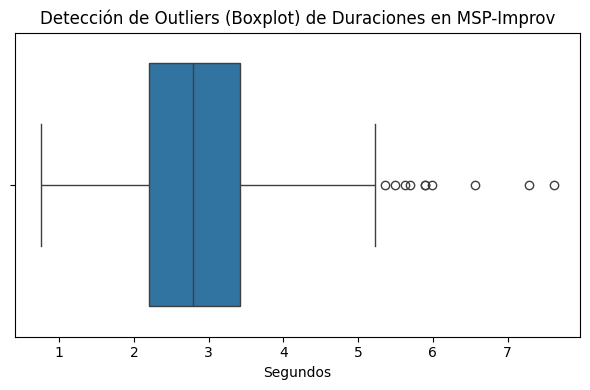

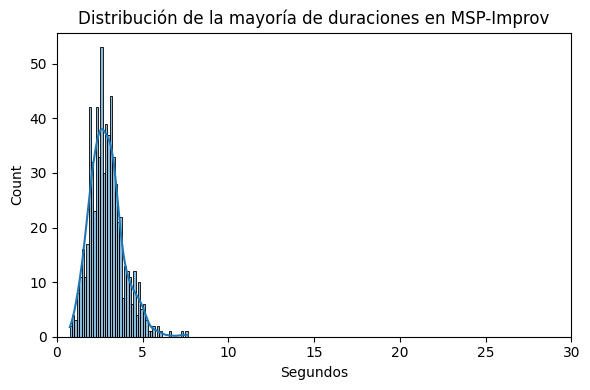

 Top 5 vídeos más largos:
                        file_id  duration
270  MSP-IMPROV-S08S-F05-T-FM01  7.624283
574  MSP-IMPROV-S08A-F05-T-FM01  7.290617
364  MSP-IMPROV-S08N-F05-T-FM01  6.556550
357  MSP-IMPROV-S10S-F05-T-FM01  5.989317
105  MSP-IMPROV-S04S-F05-T-FM01  5.889217


In [10]:
# Primero, observamos las estadísticas y una gráfica con la distribución de estas duraciones, y en base a esto decidimos el punto de corte

# Observamos las estadísticas básicas media (mean), máximo (max) y la desviación (std)
stats = df_msp['duration'].describe()
print("Estadísticas de duración (segundos):")
print(stats)


# Gráfico 1: Boxplot (Caja y Bigotes) - Para los outliers lejanos
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_msp['duration'])
plt.title('Detección de Outliers (Boxplot) de Duraciones en MSP-Improv')
plt.xlabel('Segundos')

plt.tight_layout()

# Guardamos la imagen:
plt.savefig(os.path.join(FIGURAS_PATH,"Fig_Procesamiento_MSP-Improv_Boxplot.png"), dpi=300)

plt.show()

# Gráfico 2: Histograma (Zoom en la zona normal)
plt.figure(figsize=(6, 4))
sns.histplot(df_msp['duration'], bins=50, kde=True)
plt.xlim(0, 30) 
plt.title('Distribución de la mayoría de duraciones en MSP-Improv')
plt.xlabel('Segundos')

plt.tight_layout()

# Guardamos la imagen:
plt.savefig(os.path.join(FIGURAS_PATH,"Fig_Procesamiento_MSP-Improv_Histograma.png"), dpi=300)

plt.show()

# Mostramos los 5 vídeos más largos para confirmar que son o no errores
print(" Top 5 vídeos más largos:")
print(df_msp[['file_id', 'duration']].sort_values(by='duration', ascending=False).head(5))

Al ser la media de, aproximadamente 3 segundos, y alcanzando el clip de máxima duración 7 segundos, todos los vídeos son válidos y no eliminamos ninguno. Gracias a la comprobación previa realizada de que las duraciones de los clips de audio se encuentran en un margen de 0.5 segundos con respecto a las duraciones de los clips de vídeo, este resultado también aplicaría al audio. 

#### **7. Detección de posibles **IDs duplicados**:**

En el punto **3** se determinó la ausencia de registros duplicados completos, pero este punto específico es necesario en el preprocesamiento de los datos, ya que si existieran colisiones en los **IDs** asignados a las instancias, dificultaría la entrada de los datos al modelo y la carga de los mismos por parte del DataLoader. 

In [10]:
# Verificamos si hay IDs duplicados
# Usamos Dialogue_ID + Utterance_ID como clave única
ids_duplicados = df_msp.duplicated(subset=['file_id']).sum()
print(f"IDs duplicados (file_id): {ids_duplicados}")

IDs duplicados (file_id): 0


No hay ningún ID duplicado, por tanto 'file_id' es un identificador correcto.

#### **9. Limpieza y normalización del texto:**

In [17]:
# --- LIMPIEZA Y NORMALIZACIÓN DE TEXTO ---

def limpiar_texto(texto):
    """
    Función para corregir caracteres corruptos (mojibake) y decodificar entidades HTML.
    Ejemplo: "company’s" -> "company's"
    """
    if pd.isna(texto):
        return ""
    
    t = str(texto)
    
    # 1. Se decodifican las entidades HTML (por si hay &amp; o &quot;)
    t = html.unescape(t)
    
    # 2. Se corrigen los carácteres de codificación Windows-1252 rotos
    # Se indica explícitamente el código Unicode, para asegurar que independientemente del navegador o editor de código, 
    # el cual puede internamente representar el carácter de forma distinta, asegurar que se corrigen adecuadamente
    t = t.replace('\u0092', "'") # Apóstrofe
    t = t.replace('\u2018', "'")# Comilla simple izq
    t = t.replace('\u2019', "'") # Comilla simple der
    t = t.replace('\u201C', '"') # Comilla doble izq
    t = t.replace('\u201D', '"')  # Comilla doble der
    t = t.replace('\u2026', '...') # Puntos suspensivos
    t = t.replace('\u2013', '-')  # Guión largo
    
    # 3. Eliminar espacios duplicados
    t = re.sub(r'\s+', ' ', t).strip()

    # 4. De acuerdo al análisis inicial, en la creación del DataFrame, se han observado que ciertas transcripciones cuentan con etiquetas como [Jorgensen 00:01:31] o <inaudible>, las eliminamos a continuación con regex:
    
    # ----> Eliminamos corchetes y su contenido (ej: [Jorgensen 00:01:31])
    texto_limpio = re.sub(r'\[.*?\]', '', texto)
    
    # ---> Eliminamos símbolos <> y su contenido (ej: <inaudible>, <laughter>)
    texto_limpio = re.sub(r'<.*?>', '', texto_limpio)
    
    # ---> Limpiamos espacios dobles o triples que se hayan quedado al borrar las etiquetas
    texto_limpio = re.sub(r'\s+', ' ', texto_limpio)
    
    # Eliminamos espacios al principio y al final
    return texto_limpio.strip()

# Se aplica la limpieza al campo de transcripcion:
df_msp['transcripcion'] = df_msp['transcripcion'].apply(limpiar_texto)
df_msp.head()

,file_id,session,escenario,emocion_target,transcripcion,path_video,path_audio,activacion,valencia,dominancia,target_stress,valid_check,valid_msg,duration
0,MSP-IMPROV-S07A-M01-T-MF01,session1,T,A,I am going shopping.,./data/RAW/MSP-Improv/Video/session1/S07A/T/MS...,./data/RAW/MSP-Improv/Audio/session1/S07A/T/MS...,3.200000,2.360000,3.200000,0,True,OK,1.384717
1,MSP-IMPROV-S03A-F03-T-FM01,session3,T,A,Ella made the pudding.,./data/RAW/MSP-Improv/Video/session3/S03A/T/MS...,./data/RAW/MSP-Improv/Audio/session3/S03A/T/MS...,2.840000,1.720000,3.400000,0,True,OK,3.219883
2,MSP-IMPROV-S01H-M06-T-MF01,session6,T,H,How can I not?!,./data/RAW/MSP-Improv/Video/session6/S01H/T/MS...,./data/RAW/MSP-Improv/Audio/session6/S01H/T/MS...,2.678571,4.321429,3.714286,0,True,OK,1.584917
3,MSP-IMPROV-S03H-F03-T-FM01,session3,T,H,Ellen Jorgensen made the pudding .,./data/RAW/MSP-Improv/Video/session3/S03H/T/MS...,./data/RAW/MSP-Improv/Audio/session3/S03H/T/MS...,2.689655,3.241379,3.708333,0,True,OK,3.186517
4,MSP-IMPROV-S10A-M06-T-MF01,session6,T,A,I don't know how she could miss this opportunity.,./data/RAW/MSP-Improv/Video/session6/S10A/T/MS...,./data/RAW/MSP-Improv/Audio/session6/S10A/T/MS...,3.076923,2.576923,3.500000,0,True,OK,4.454450


#### **10. Generación variable objetivo binaria de Estrés:** 

Para construir la variable objetivo, utilizaremos las variables numéricas continuas de valencia, activación y dominancia. Los autores indican que estas se encuentran en escala Likert (1-5), siendo el umbral teórico de 3.0, pero, para asegurarnos, calculamos primero la mediana de las puntuaciones reales del corpus, y tomamos como umbral para el mapeo el mayor valor. 

In [18]:
# 1. Calculamos la media y la mediana real de nuestros datos:
mediana_v = df_msp['valencia'].median()
mediana_a = df_msp['activacion'].median()

media_v = df_msp['valencia'].mean()
media_a = df_msp['activacion'].mean()

print(f"VALENCIA: Teórico: 3.0 | Mediana Real: {mediana_v:.2f} | Media: {media_v:.2f}")
print(f"ACTIVACIÓN: Teórico: 3.0 | Mediana Real: {mediana_a:.2f} | Media: {media_a:.2f}")


VALENCIA: Teórico: 3.0 | Mediana Real: 2.70 | Media: 2.80
ACTIVACIÓN: Teórico: 3.0 | Mediana Real: 3.39 | Media: 3.32


Al ser la mediana, para ambas variables, diferente de la teórica (en base a la escala Likert del 1 al 5), seleccionamos como umbral las propias medianas en ambos casos para el mapeo:

In [19]:
# 2. Decisión metodológica: 

UMBRAL_V = mediana_v
UMBRAL_A = mediana_a  

def etiquetar_estres(row):
    # Estrés = Alta Activación Y Baja Valencia
    if row['activacion'] > UMBRAL_A and row['valencia'] < UMBRAL_V:
        return 1
    else:
        return 0

# 3. Aplicamos la lógica
df_msp['target_stress'] = df_msp.apply(etiquetar_estres, axis=1)

# 4. Verificamos el desbalanceo resultante
print("\nResultado de la binarización:")
display(df_msp['target_stress'].value_counts(normalize=True) * 100)


Resultado de la binarización:


target_stress
0    76.769231
1    23.230769
Name: proportion, dtype: float64

Vemos, al igual que ocurría en MELD, y levemente en IEMOCAP,
en este dataset también se presenta un desbalanceo crítico. 

------
## **Carga (Load) en `MSP-Improv_clean.csv`**

In [20]:
# --- GUARDADO DEL DATASET PREPROCESADO RESULTANTE (MSP-Improv) ---

# 1. Definimos las columnas finales adaptadas a la estructura de MSP-Improv:
cols_finales = [
    'file_id',  # Identificador único de la muestra
    'transcripcion', # Texto crudo/limpio del turno
    'emocion_target',# Emoción original del directorio (A, H, S, N)
    'valencia', # Valor continuo (para auditoría)
    'activacion', # Valor continuo (para auditoría)
    'target_stress', # Nuestro target binario de estrés (Russell)
    'path_video', # Ruta relativa al vídeo
    'path_audio', # Ruta relativa al audio .wav
    'duration', # Duración obtenida en el Sanity Check
    'session', # Sesión (session1-6) 
    'escenario' # Escenario (en este caso siempre será 'T')
]

# Creamos el dataframe limpio
df_msp_clean = df_msp[cols_finales]

print(f"Total de muestras válidas: {len(df_msp_clean)}")
print("\nVista previa del dataset resultante:")
display(df_msp_clean.head())

Total de muestras válidas: 650

Vista previa del dataset resultante:


,file_id,transcripcion,emocion_target,valencia,activacion,target_stress,path_video,path_audio,duration,session,escenario
0,MSP-IMPROV-S07A-M01-T-MF01,I am going shopping.,A,2.360000,3.200000,0,./data/RAW/MSP-Improv/Video/session1/S07A/T/MS...,./data/RAW/MSP-Improv/Audio/session1/S07A/T/MS...,1.384717,session1,T
1,MSP-IMPROV-S03A-F03-T-FM01,Ella made the pudding.,A,1.720000,2.840000,0,./data/RAW/MSP-Improv/Video/session3/S03A/T/MS...,./data/RAW/MSP-Improv/Audio/session3/S03A/T/MS...,3.219883,session3,T
2,MSP-IMPROV-S01H-M06-T-MF01,How can I not?!,H,4.321429,2.678571,0,./data/RAW/MSP-Improv/Video/session6/S01H/T/MS...,./data/RAW/MSP-Improv/Audio/session6/S01H/T/MS...,1.584917,session6,T
3,MSP-IMPROV-S03H-F03-T-FM01,Ellen Jorgensen made the pudding .,H,3.241379,2.689655,0,./data/RAW/MSP-Improv/Video/session3/S03H/T/MS...,./data/RAW/MSP-Improv/Audio/session3/S03H/T/MS...,3.186517,session3,T
4,MSP-IMPROV-S10A-M06-T-MF01,I don't know how she could miss this opportunity.,A,2.576923,3.076923,0,./data/RAW/MSP-Improv/Video/session6/S10A/T/MS...,./data/RAW/MSP-Improv/Audio/session6/S10A/T/MS...,4.454450,session6,T


In [21]:
df_msp_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   file_id         650 non-null    str    
 1   transcripcion   650 non-null    str    
 2   emocion_target  650 non-null    str    
 3   valencia        650 non-null    float64
 4   activacion      650 non-null    float64
 5   target_stress   650 non-null    int64  
 6   path_video      650 non-null    str    
 7   path_audio      650 non-null    str    
 8   duration        650 non-null    float64
 9   session         650 non-null    str    
 10  escenario       650 non-null    str    
dtypes: float64(3), int64(1), str(7)
memory usage: 56.0 KB


-----
## **Extracción de características**:

Para la evaluación de transferencia de aprendizaje del modelo global multimodal seleccionado finalmente (fusión mediante atención), extraemos las características fijando las ventanas óptimas de dicha arquitectura (dejando el resto de hiperparámetros estándar del modelo base cargado, al igual que hicimos en los notebooks de extracción):

* **VENTANAS DE LA ARQUITECTURA GLOBAL MULTIMODAL AJUSTADA**:
  * **Vídeo (ResNet)**: 32 frames
  * **Audio (Wav2Vec 2.0)**: 7 segundos
  * **Texto (RoBERTa)**: 32 tokens

* **VENTANAS DE LOS BASELINES DE CADA MODELO UNIMODAL AJUSTADO**:
  * **Vídeo (ResNet)**: 32 frames
  * **Audio (Wav2Vec 2.0)**: 7 segundos
  * **Texto (RoBERTa)**: 64 tokens (además de la ventana de 32 tokens, la extraemos con ventana de 64 tokens)

Reutilizamos las mismas funciones utilizadas para el notebook de **Extracción de Características Visuales para MELD e IEMOCAP**, pero adaptándolas a MSP-Improv:

* Embeddings visuales (**32 frames**) con `ResNet50`:

In [22]:
def resnet_extractor():
    """
    Carga ResNet50 pre-entrenada y elimina la capa de clasificación (FC).
    Devuelve:
    - model: El modelo extractor listo para usar.
    - output_dim: 2048 (Número de características por frame)
    """
    
    # Cargamos los pesos entrenados en ImageNet. Esto asegura que la red sepa ya reconocer formas, luces y texturas (sesgo inductivo de la CNN):
    weights = models.ResNet50_Weights.IMAGENET1K_V1 ### ResNet50_Weights.DEFAULT == ResNet50_Weights.IMAGENET1K_V2, por eso no hemos elegido la DEFAULT, ya que la V2 es una versión mejorada del pipeline de entrenamiento (sobre el mismo dataset de ImageNet-1K), lo que haría la comparativa con respecto a ViT y a EfficientNet injusta. Con V1 seleccionamos los pesos obtenidos del modelo con el pipeline estándar básico de entrenamiento (sobre el mismo dataset ImageNet-1K) 
    model = models.resnet50(weights=weights)
    
    # ----- ELIMINAMOS ÚLTIMA CAPA DE CLASIFICACIÓN -----
    # La arquitectura ResNet original termina en una capa 'fc' (Linear) que clasifica en 1000 clases.
    # Nosotros queremos el vector justo antes de esa clasificación
    modules = list(model.children())[:-1] # Con list(model.children())[:-1] cogemos todas las capas menos la última
    model = nn.Sequential(*modules) # Creamos un nuevo modelo con todas las capas excepto la última
    
    # Congelamos los pesos (Freeze), ya que no queremos entrenar la CNN, solo usarla directamente:
    for param in model.parameters():
        param.requires_grad = False
        
    model.to(device)
    model.eval() # Ponemos en modo evaluación 
    
    return model, 2048  # ResNet50 siempre devuelve vectores de tamaño 2048

# Definimos también las transformaciones que ResNet (al igual que EfficientNet y ViT) necesita para funcionar:
# Son reglas estrictas de ImageNet: normalización con media/std específicos
preprocess = transforms.Compose([ 
    transforms.Resize(256), # Redimensionamos a 256x256
    transforms.CenterCrop(224), # Recortamos al centro para quedarnos con 224x224, que es el tamaño que ResNet y EfficientNet esperan
    transforms.ToTensor(), # Convertimos a tensor (esto también escala los píxeles a [0,1])
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalización específica de ImageNet
])

In [23]:
# ------------------------------------------------------------------------
# 1. Definición del Dataset para Carga Paralela (Multiprocessing)
# ------------------------------------------------------------------------
class MSPImprovVideoDataset(Dataset):
    def __init__(self, df, transform=None, num_frames =32):
        """
        Args:
            df: DataFrame (MSP-Improv_clean.csv)
            transform: Transformaciones (ej. Resize, Normalize, ToTensor)
            num_frames: Número de frames fijos (debe coincidir con el modelo global, por tanto 32)
        """
        self.df = df
        self.transform = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)
    
    def extract_frames(self, video_path):
        """
        Abre un vídeo y extrae 'num_frames' imágenes distribuidas uniformemente.
        Devuelve: Una lista de imágenes en formato PIL.
        """
        # Abrimos el vídeo con OpenCV (en formato BGR, que es el formato nativo de OpenCV y evita gasto de CPU en convertir a RGB si no es necesario)
        cap = cv2.VideoCapture(video_path)
    
        # Verificamos si el vídeo abre
        if not cap.isOpened():
            return [] # Si no se puede abrir el vídeo, devolvemos una lista vacía

        # Leemos todos los frames del vídeo y los almacenamos en una lista:
        all_frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break # Si no se pueden leer más frames, salimos del bucle, ya que hemos leído todos los frames disponibles
            all_frames.append(frame) # Guardamos BGR 
    
        cap.release() # Cerramos el vídeo para liberar recursos

        total_frames = len(all_frames)
        if total_frames == 0:
            return []  # Por seguridad, si el vídeo no tiene frames, devolvemos una lista vacía

        # Calculamos qué índices coger, con np.linspace creamos una secuencia espaciada uniformemente (ej: 0, 5, 10...)
        indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        # Esto asegura que aunque el vídeo tenga menos de 'num_frames', no se generarán índices fuera del rango, y se repetirá el último frame según sea necesario
    
        # Solo convertimos a RGB y PIL los 32 frames seleccionados, para evitar gasto de CPU en convertir a RGB los frames que no vamos a usar:
        selected_frames = []
        for i in indices:
            frame_bgr = all_frames[i]
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            selected_frames.append(Image.fromarray(frame_rgb))
    
        # Padding de seguridad si el video era muy corto (menos de 32 frames), repetimos el último frame hasta completar los 32:
        while len(selected_frames) < self.num_frames:
            selected_frames.append(selected_frames[-1])
        
        return selected_frames

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = row['path_video']
        file_id = row['file_id']
        
        # Extracción de 32 frames uniformes del vídeo
        frames = self.extract_frames(video_path)
        if self.transform and len(frames) > 0:
            frames = torch.stack([self.transform(f) for f in frames]) # torch.stack --> (num_frames, canales, alto, ancho)
        
        return frames, file_id
    


# -------------------------------------------------------------------------
# 2. Lógica Principal de Extracción
# -------------------------------------------------------------------------
def main_extraction_msp_improv(df, output_dir, preproc, num_workers=8):
    """
    Función principal de extracción diseñada para ejecución paralela en Servidor DGX.
    Args:
    - df: DataFrame preprocesado de MSP-Improv
    - output_dir: Nombre del directorio de salida donde se almacenarán los embeddings
    - preproc: pipeline de preprocesamiento para el modelo
    - root_msp_path: ruta del directorio donde se encuentran los clips de vídeo de MSP-Improv
    - num_workers (int): Número de procesos paralelos para DataLoader.
    Devuelve:
    - Guarda los embeddings extraídos en archivos .npy en el directorio correspondiente.
    """
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(output_dir, exist_ok=True)

    # 1. Carga de datos:
    dataset = MSPImprovVideoDataset(df, transform=preproc)
    dataloader = DataLoader(dataset, batch_size=1, num_workers=num_workers)

    # 2. Carga del modelo:
    model, dim = resnet_extractor()
    
    # 3. Extracción paralela:
    with torch.no_grad():
        for frames, name in tqdm(dataloader, desc=f"Extrayendo embeddings visuales..."):
            file_name = name[0]
            output_path = os.path.join(output_dir, f"{file_name}.npy")

            if frames.numel() == 0  or os.path.exists(output_path):  #con .numel devuleve el número de elementos del tensor, si este está vacío, devuelve 0
                continue
            
            frames = frames.squeeze(0).to(device) # Shape: (32, 3, 224, 224)
            embeddings = model(frames) # (32, 2048, 1, 1)
            # Embeddings shape :
            # ResNet -> (32, Dim, 1, 1) -> Necesitamos aplicar flatten
            embeddings = embeddings.flatten(start_dim=1)
            
            np.save(output_path, embeddings.cpu().numpy())
    




# -------------------------------------------------------------------------
# EJECUCIÓN
# -------------------------------------------------------------------------

if __name__ == '__main__':

    output_dir_path = os.path.join(LOCAL_DATA_ROOT_VISUAL)
        
    main_extraction_msp_improv(
        df=df_msp_clean,
        output_dir = output_dir_path,
        preproc = preprocess
    )

    # Sanity check:
    print("EJECUTANDO SANITY CHECK DE EMBEDDINGS VISUALES: ")

    # 1. Contamos archivos generados
    archivos_generados = [f for f in os.listdir(output_dir_path) if f.endswith('.npy')]
    total_esperado = len(df_msp_clean)
    total_real = len(archivos_generados)

    print(f"-> Muestras en el DataFrame: {total_esperado}")
    print(f"-> Archivos .npy detectados: {total_real}")

    if total_real == total_esperado:
        print("El número de archivos coincide.")
    else:
        print(f"Hay una diferencia de {abs(total_esperado - total_real)} archivos.")

    # 2. Verificar integridad y shape de un ejemplo aleatorio
    if total_real > 0:
        ejemplo_nombre = archivos_generados[0]
        ejemplo_path = os.path.join(output_dir_path, ejemplo_nombre)
        ejemplo_emb = np.load(ejemplo_path)

        print(f"\nAnalizando ejemplo: {ejemplo_nombre}")
        print(f"-> Shape del embedding: {ejemplo_emb.shape}")
        
        # Verificación de dimensiones (32, 2048)
        if ejemplo_emb.shape == (32, 2048):
            print("Estructura correcta: [32 frames, 2048 dimensiones]")
        else:
            print(f"Error de dimensiones: Se esperaba (32, 2048) y se obtuvo {ejemplo_emb.shape}")
            
        # Verificar que no hay valores NaN o Inf:
        if np.isnan(ejemplo_emb).any() or np.isinf(ejemplo_emb).any():
            print("Error: Se han detectado valores NaN o Infinitos en el archivo.")
        else:
            print("Integridad numérica: No hay valores nulos ni infinitos.")
    else:
        print("Error: No se han encontrado archivos para analizar.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:00<00:00, 103MB/s]
Extrayendo embeddings visuales...: 100%|███████████████████████████████████████████| 650/650 [01:12<00:00,  8.91it/s]

EJECUTANDO SANITY CHECK DE EMBEDDINGS VISUALES: 
-> Muestras en el DataFrame: 650
-> Archivos .npy detectados: 650
El número de archivos coincide.

Analizando ejemplo: MSP-IMPROV-S05H-F02-T-FM01.npy
-> Shape del embedding: (32, 2048)
Estructura correcta: [32 frames, 2048 dimensiones]
Integridad numérica: No hay valores nulos ni infinitos.


* Embeddings acústicos (**7 segundos**) con `Wav2Vec 2.0`:

In [26]:
# --- 1. Se carga inicialmente el modelo WAV2VEC 2.0 ---

def extract_wav2vec(audio_path,feature_extractor,model, target_steps=350):
    """
    Con el modelo Wav2Vec 2.0 Base cargado previamente, extrae embeddings de audio.
    Retorna embeddings de tamaño (Time_Steps, 768).
    Sampling Rate obligatorio: 16000 Hz.
    """
    try:
        # Cargamos audio con obligatoriamente 16kHz:
        y, sr = librosa.load(audio_path, sr=16000, mono = True) # Indicamos explícitamente que mono es True (aunque ya este valor está por defecto)
        
        # Aplicamos preprocesamiento:
        inputs = feature_extractor(y, sampling_rate=16000, return_tensors="pt", padding=True)
        input_values = inputs.input_values.to(device)
        
        with torch.no_grad():
            outputs = model(input_values)
            # outputs.last_hidden_state tiene forma (1, T, 768) -> quitamos el batch con squeeze
            embeddings = outputs.last_hidden_state.squeeze(0)
            
        # --------------- 7 SEGUNDOS (350 PASOS) ----------------

        seq_len = embeddings.size(0)

        if seq_len > target_steps:
            # Truncamos si es más largo
            embeddings = embeddings[:target_steps, :]
        elif seq_len < target_steps:
            # Padding con ceros si es más corto
            padding = torch.zeros((target_steps - seq_len, 768), device=device)
            embeddings = torch.cat([embeddings, padding], dim=0)

        return embeddings.cpu().numpy()
    
    except Exception as e:
        print(f"Error procesando {audio_path}: {e}")
        return None

In [27]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
wav2vec_model.eval()

for index, row in tqdm(df_msp_clean.iterrows(), total=len(df_msp_clean), desc="Extrayendo embeddings de audio..."):
    file_id = row['file_id']
    audio_path = row['path_audio']

    out_path = os.path.join(LOCAL_DATA_ROOT_AUDIO, f"{file_id}.npy")

    # Si ya existe, saltamos:
    if os.path.exists(out_path):
        continue
        
    if os.path.exists(audio_path):
        emb = extract_wav2vec(audio_path, feature_extractor, wav2vec_model)

        if emb is not None:
            np.save(out_path, emb)

# --- SANITY CHECK FINAL ---
archivos_audio = [f for f in os.listdir(LOCAL_DATA_ROOT_AUDIO) if f.endswith('.npy')]
print(f"\nExtracción completada: {len(archivos_audio)}/{len(df_msp_clean)}")

if len(archivos_audio) > 0:
    ejemplo = np.load(os.path.join(LOCAL_DATA_ROOT_AUDIO, archivos_audio[0]))
    print(f"Shape detectado: {ejemplo.shape}")
    if ejemplo.shape == (350, 768):
        print("Configuración correcta para 7 segundos (350 pasos).")
    else:
        print(f"Error de dimensiones: {ejemplo.shape}")

Extrayendo embeddings de audio...: 100%|██████████████████████████████████████████| 650/650 [00:05<00:00, 119.94it/s]


Extracción completada: 650/650
Shape detectado: (350, 768)
Configuración correcta para 7 segundos (350 pasos).


* Embeddings textuales (**32 tokens**) con `RoBERTa`:

In [ ]:
def extract_features(df, model_name, tokenizer, model, max_len, output_dir):
    """
    Función para extraer características textuales utilizando un modelo de Hugging Face dado.
    
    Args:
        df (pd.DataFrame): DataFrame con las transcripciones y metadatos de MSP-Improv
        model_name (str): Nombre del modelo (e.g., 'bert', 'roberta', 'deberta').
        tokenizer: Tokenizador del modelo seleccionado.
        model: Modelo ya cargado y en modo evaluación (inferencia)
        max_len (int): Longitud máxima de la ventana de texto (tokens)
        output_dir (str): Directorio donde se guardarán los embeddings extraídos.
    
    Devuelve:
        None (los embeddings se guardan como archivos .npy en el directorio especificado).
    """
    os.makedirs(output_dir, exist_ok=True)  # Crear el directorio de salida si no existe  

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Extrayendo características con {model_name} (max_len={max_len})", file = sys.stdout, position=0, leave=True):
        file_id = row['file_id']
        file_path = os.path.join(output_dir, f"{file_id}.npy")

        if os.path.exists(file_path): # Reanudación si se corta la ejecución
            continue

        transcription = row['transcripcion']

        # Tokenización y creación de tensores
        inputs = tokenizer(transcription, # Tokenizamos la transcripción
                            return_tensors='pt', # Devolvemos tensores PyTorch
                            truncation=True,  # Truncamos el texto si excede max_len
                            padding='max_length',  # Rellenamos con ceros hasta max_len
                            max_length=max_len) # Establecemos la longitud máxima de la ventana
        inputs = {key: val.to(device) for key, val in inputs.items()}

        # Extracción de características sin calcular gradientes (inferencia):
        with torch.no_grad(): 
            outputs = model(**inputs) # Obtenemos las salidas del modelo (embeddings)
            # Guardamos el embedding de la secuencia completa:
            embedding = outputs.last_hidden_state.squeeze(0).cpu().numpy() 

        # Guardar el embedding como un archivo .npy
        np.save(file_path, embedding)  # Guardamos el embedding en un archivo .npy

# Cargamos RoBERTa:
tokenizador = AutoTokenizer.from_pretrained("roberta-base")
modelo = AutoModel.from_pretrained("roberta-base").to(device)
modelo.eval()

extract_features(df_msp_clean, 
                 "roberta", 
                 tokenizador, 
                 modelo, 
                 32, 
                 LOCAL_DATA_ROOT_TEXTO_32)

# --- SANITY CHECK FINAL ---
archivos_texto = [f for f in os.listdir(LOCAL_DATA_ROOT_TEXTO_32) if f.endswith('.npy')]
print(f"\nExtracción completada: {len(archivos_texto)}/{len(df_msp_clean)}")

if len(archivos_texto) > 0:
    ejemplo = np.load(os.path.join(LOCAL_DATA_ROOT_TEXTO_32, archivos_texto[0]))
    print(f"Shape detectado: {ejemplo.shape}")


Loading weights: 100%|███████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 5630.44it/s]


Extrayendo características con roberta (max_len=32): 100%|████████████████████████| 650/650 [00:04<00:00, 151.10it/s]

Extracción completada: 650/650
Shape detectado: (32, 768)


* Embeddings textuales (**64 tokens**) con `RoBERTa`:

In [11]:
# Cargamos RoBERTa:
tokenizador = AutoTokenizer.from_pretrained("roberta-base")
modelo = AutoModel.from_pretrained("roberta-base").to(device)
modelo.eval()

extract_features(df_msp_clean, 
                 "roberta", 
                 tokenizador, 
                 modelo, 
                 64, 
                 LOCAL_DATA_ROOT_TEXTO_64)

# --- SANITY CHECK FINAL ---
archivos_texto = [f for f in os.listdir(LOCAL_DATA_ROOT_TEXTO_64) if f.endswith('.npy')]
print(f"\nExtracción completada: {len(archivos_texto)}/{len(df_msp_clean)}")

if len(archivos_texto) > 0:
    ejemplo = np.load(os.path.join(LOCAL_DATA_ROOT_TEXTO_64, archivos_texto[0]))
    print(f"Shape detectado: {ejemplo.shape}")

Loading weights: 100%|██████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 5586.28it/s]


Extrayendo características con roberta (max_len=64): 100%|█████████████████████████| 650/650 [00:00<00:00, 33098.59it/s]

Extracción completada: 650/650
Shape detectado: (64, 768)


Además, por ser el baseline unimodal de BERT el que mayor rendimiento obtuvo, extraemos los embeddings de BERT con su ventana óptima seleccionada de 64 tokens: 

* Embeddings textuales (**64 tokens**) con `BERT`:

In [9]:
# Cargamos RoBERTa:
tokenizador = AutoTokenizer.from_pretrained("bert-base-uncased")
modelo = AutoModel.from_pretrained("bert-base-uncased").to(device)
modelo.eval()

extract_features(df_msp_clean, 
                 "bert", 
                 tokenizador, 
                 modelo, 
                 64, 
                 LOCAL_DATA_ROOT_TEXTO_64_BERT)

# --- SANITY CHECK FINAL ---
archivos_texto = [f for f in os.listdir(LOCAL_DATA_ROOT_TEXTO_64_BERT) if f.endswith('.npy')]
print(f"\nExtracción completada: {len(archivos_texto)}/{len(df_msp_clean)}")

if len(archivos_texto) > 0:
    ejemplo = np.load(os.path.join(LOCAL_DATA_ROOT_TEXTO_64_BERT, archivos_texto[0]))
    print(f"Shape detectado: {ejemplo.shape}")

Loading weights: 100%|██████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 6781.66it/s]


Extrayendo características con bert (max_len=64): 100%|██████████████████████████████| 650/650 [00:04<00:00, 149.33it/s]

Extracción completada: 650/650
Shape detectado: (64, 768)


---------
## **Particionamiento**

Como prueba final en la evaluación de la transferencia de aprendizaje, la arquitectura multimodal óptima obtenida sobre MELD e IEMOCAP se entrenará sobre MSP-Improv + MELD y MSP-Improv + IEMOCAP, y se enfrentará sobre IEMOCAP y MELD, respectivamente, para asegurar que la capacidad de generalización y transferencia del modelo es robusta y se da en cualquier situación, independientemente del dominio. 

Para ello, como se utiliza MSP-Improv para el entrenamiento en estos casos, es necesario realizar el particionamiento en **train** y **dev** (**test** no, ya que en la evaluación de transferencia de aprendizaje, se evalúa el modelo sobre el tercer dataset).

Para ello, siguiendo la misma lógica de particionamiento aplicada para MELD e IEMOCAP con el objetivo de evitar el sesgo del hablante, de divide en base a las sesiones. Previamente al particionamiento, se analiza la proporción de muestras de estrés en cada partición:


In [18]:
# Proporción de muestras por cada sesión:

display(
    df_msp_clean.groupby('session')['target_stress']
          .value_counts(normalize=True)
          .mul(100)
          .rename('percentage')
)


Resultado de la binarización:


session   target_stress
session1  0                73.750000
          1                26.250000
session2  0                71.074380
          1                28.925620
session3  0                78.651685
          1                21.348315
session4  0                78.333333
          1                21.666667
session5  0                76.666667
          1                23.333333
session6  0                81.666667
          1                18.333333
Name: percentage, dtype: float64

Al estar equilibrada la proporción en todas las sesiones (aprox. de un 20% en cada una para la clase positiva, presentando la session 1 la mayor cantidad), el particionamiento se realizará de la siguiente forma:
* **Train**: `session1`, `session2`, `session3`, `session5`
* **Dev**: `session4`, `session6`

Las sesiones con mayor número de muestras positivas van a parar a train para aliviar el problema del desbalanceo, y las restantes pasan a validación:

In [26]:
def asignar_split_mspimprov(session):
    if session in ['session1', 'session2', 'session3', 'session5']:
        return 'train'
    else:
        return 'dev'  # sesiones 4 y 6


df_msp_clean['split'] = df_msp_clean['session'].apply(asignar_split_mspimprov)

# ---------------------- VERIFICACIÓN ------------------------------
print("Comprobación de splits:")
print(df_msp_clean.groupby('split').size())

Comprobación de splits:
split
dev      240
train    410
dtype: int64


In [27]:
display(
    df_msp_clean.groupby('split')['target_stress']
          .value_counts(normalize=True)
          .mul(100)
          .rename('percentage')
)

split  target_stress
dev    0                80.000000
       1                20.000000
train  0                74.878049
       1                25.121951
Name: percentage, dtype: float64

In [29]:
# Creamos el directorio si no existe
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Guardamos el CSV
output_file = os.path.join(PROCESSED_PATH, "MSP-Improv_clean.csv")
df_msp_clean.to_csv(output_file, index=False)